In [381]:
import nupack as nu 
import numpy as np 
from seqwalk import design
import math
import sys
import random 
import csv
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from tqdm import tqdm

# import custom modules
if 'barcodes' in sys.modules:
    del sys.modules['barcodes']
if 'toeholds' in sys.modules:
    del sys.modules['toeholds']
if 'finalize_seqs' in sys.modules:
    del sys.modules['finalize_seqs']
if 'analysis' in sys.modules:
    del sys.modules['analysis']

from orthogonal import *
from barcodes import *
from toeholds import *
from finalize_seqs import *
from analysis import *

In [153]:
"""
Save the _pool data to a CSV file.

Args:
    pool: List of tuples (top_strands, bottom_strands) for each CDS
    filename: Output CSV filename
"""
def save_to_csv(pool, filename="sidewinder_strands.csv"):
    with open(filename, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        
        # Write header
        writer.writerow(['CDS_Index', 'Strand_Type', 'Strand_Index', 'Sequence'])
        
        # Write data
        for cds_idx, (top_strands, bottom_strands) in enumerate(pool):
            # Write top strands
            for strand_idx, strand in enumerate(top_strands):
                writer.writerow([cds_idx, 'top', strand_idx, strand])
            
            # Write bottom strands
            for strand_idx, strand in enumerate(bottom_strands):
                writer.writerow([cds_idx, 'bottom', strand_idx, strand])

In [154]:
# Settings 
oligo_length = 150 
barcode_length = 18 
fragment_length = oligo_length - 2 * barcode_length
max_final_c_domain_length = oligo_length - barcode_length
toehold_length = 10
toehold_search_range = 15
identity_threshold = 0.6
args = oligo_length, barcode_length, fragment_length, max_final_c_domain_length, toehold_length, toehold_search_range, identity_threshold

model =nu.Model(material="dna", celsius=50)
ncores = mp.cpu_count()
conc = 1e-8

In [85]:
# import CDS sequences
CDS_sequences = []
filename = "test_native_CDS_first_24_no_Hip205.csv"
with open(filename, "r",encoding='utf-8-sig') as f:
    reader = csv.reader(f)
    for row in reader:
        if len(row) > 0:
            CDS_sequences.append(row[0])

## String based generation

In [355]:
# string generation 
string_pool = []
toehold_idx_seps = [0]
all_putative_toeholds = []
# generate the set of all toeholds for all CDSs
print("Generating toeholds")
for cds_idx, cds in enumerate(CDS_sequences):    
    putative_toeholds = generate_putative_toeholds(cds, args)
    all_putative_toeholds += putative_toeholds
    toehold_idx_seps.append(len(all_putative_toeholds))

combinations = toehold_combinations(all_putative_toeholds, args, int(1e2))
data = evaluate_combinations_string(combinations, ncores)
weights = {
        "min_edit_distance": (1.0, 1),
        "average_edit_distance": (0.5, 1)
        }
bestid = rank_combinations_weighted(data,weights)
toeholds = combinations[bestid]
toeholds_seqs = [toeholds[i][0] for i in range(len(toeholds))]

# generate barcodes
print("Generating barcodes")
barcode_sets = generate_putative_barcodes(toeholds_seqs, 7,9,barcode_length,100)
barcode_data = evaluate_barcodes_string(barcode_sets, toeholds_seqs, ncores)
weights = {
        'min_edit_distance': (1.0,1),
        'average_edit_distance': (0.5,1)
    }
best_barcodeid = rank_combinations_weighted(barcode_data, weights)
barcodes=barcode_sets[best_barcodeid]
    
# generate pairs
print("Generating pairs")
pairings = generate_pairings(toeholds_seqs,barcodes,num_sets=100)
pairings_string = [[pairs[0] + pairs[1] for pairs in pairing] for pairing in pairings]
evaluated_pairings = evaluate_pairings_string(pairings_string, ncores)
weights = {
        'longest_common_substring': (1.0,0)
    }
best_pair_id =rank_combinations_weighted(evaluated_pairings,weights)
best_pair = pairings[best_pair_id]

# generate final sidewinder strands
for i in range(len(toehold_idx_seps)-1):
    my_toeholds_with_idx = toeholds[toehold_idx_seps[i]:toehold_idx_seps[i+1]]
    my_pairs = best_pair[toehold_idx_seps[i]:toehold_idx_seps[i+1]]
    domains = get_domains(my_toeholds_with_idx, CDS_sequences[i], toehold_length)
    top_strands, bottom_strands = generate_sidewinder_strands(my_pairs, domains)
    string_pool.append((top_strands, bottom_strands))

Generating toeholds


100%|██████████| 100/100 [00:10<00:00,  9.45it/s]
/Users/acheron/miniforge3/envs/mamba/lib/python3.9/site-packages/seqwalk/design.py:28: UserWarning: Falling back to Hierholzer algorithm for odd-k, ACGT, RC free
  warn("Falling back to Hierholzer algorithm for odd-k, ACGT, RC free")


Best combination ID: 0

Individual ranks:
min_edit_distance: 3
average_edit_distance: 5

Raw data for best combination:
(3.0844107517452315, 10.644681447610226)
Generating barcodes
generated 6746 barcodes to sample from
each sampled set contains 144 barcodes


100%|██████████| 100/100 [00:55<00:00,  1.79it/s]

Best combination ID: 55

Individual ranks:
min_edit_distance: 1
average_edit_distance: 8

Raw data for best combination:
(6.0, 10.457944832944833)
Generating pairs



100%|██████████| 100/100 [00:03<00:00, 28.13it/s]

Best combination ID: 3

Individual ranks:
longest_common_substring: 1

Raw data for best combination:
[9]


let's explore performance of 8 and 9 nt longest common substrings!

In [ ]:
to_investigate = []
max_off_target_probabilities = []
average_off_target_probabilities = []
for i, val in enumerate(evaluated_pairings):
    if val[0] <= 9:
        string_pairing = []
        for pair in pairings[i]:
            string_pairing.append(pair[0] + pair[1])
        to_investigate.append(string_pairing)
        nu_mat, on_t = nupack_matrix_mp(string_pairing, model, conc, ncores, duplex=1)
        max_off_target_probabilities.append(np.max(nu_mat))
        average_off_target_probabilities.append(np.mean(nu_mat))

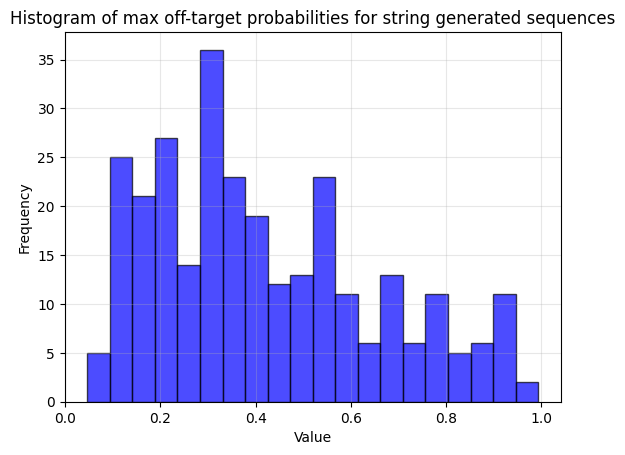

In [165]:
plt.hist(max_off_target_probabilities, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of max off-target probabilities for string generated sequences')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

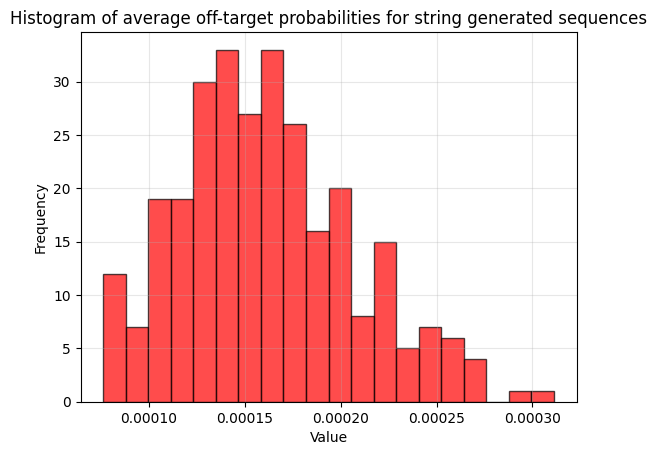

In [166]:
plt.hist(average_off_target_probabilities, bins=20, alpha=0.7, color='red', edgecolor='black')
plt.title('Histogram of average off-target probabilities for string generated sequences')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

In [389]:
save_to_csv(string_pool, "string_pool.csv")

In [173]:
string_top_strands, string_bottom_strands = top_strands, bottom_strands
string_toeholds_seqs = toeholds_seqs
string_toeholds = toeholds
string_barcodes = barcodes
string_pairings = best_pair

In [174]:
for j in range(len(CDS_sequences)):
    sum = ""
    bottom_strands = string_pool[j][1]
    for i in range(len(bottom_strands)):
        sum+= nu.reverse_complement(bottom_strands[i])
    assert(sum == CDS_sequences[j])

## String & Thermodynamic based generation

In [400]:
# thermodynamic generation
thermo_pool = []

toehold_idx_seps = [0]
all_putative_toeholds = []
# generate the set of all toeholds for all CDSs
print("Generating toeholds")
for cds_idx, cds in enumerate(CDS_sequences):    
    putative_toeholds = generate_putative_toeholds(cds, args)
    all_putative_toeholds += putative_toeholds
    toehold_idx_seps.append(len(all_putative_toeholds))

# first judge the the toeholds based on string metrics
toe_combinations = toehold_combinations(all_putative_toeholds, args, int(1e2))
toe_string_data = evaluate_combinations_string(toe_combinations, ncores)
# For top 20% 
n_top = int(np.ceil(len(toe_string_data) * 0.2))
top_20_percent_indices = np.argsort(toe_string_data)[:n_top]
weights = {
        "min_edit_distance": (1.0, 1),
        "average_edit_distance": (0.5, 1)
        }
top_20_percent_indices = rank_combinations_weighted(toe_string_data,weights,n_top)
top_toehold_combinations = toe_combinations[top_20_percent_indices]

# then judge based on thermo metrics 
toe_thermo_data = evaluate_combinations_thermo(top_toehold_combinations, model, ncores, conc)
weights = {
    'max_offtarget_probability': (2.0,0),
    'average_offtarget_probability': (2.0,0),
    'max_on_target_defect': (1.0,0),
    'average_on_target_defect': (1.0,0),
    'min_off_target_defect': (1.0,1),
    'average_off_target_defect': (1.0,1)
}
best_toe_id = rank_combinations_weighted(toe_thermo_data, weights)
toeholds = top_toehold_combinations[best_toe_id]
print(toe_thermo_data[best_toe_id])
print(toe_string_data[top_20_percent_indices[best_toe_id]])
toeholds_seqs = [toeholds[i][0] for i in range(len(toeholds))]

Generating toeholds


100%|██████████| 100/100 [00:10<00:00,  9.29it/s]

Best combination ID: 71

Individual ranks:
min_edit_distance: 1
average_edit_distance: 3

Raw data for best combination:
(4.362372232581265, 10.677569972236157)



100%|██████████| 20/20 [01:39<00:00,  4.95s/it]

Best combination ID: 12

Individual ranks:
max_offtarget_probability: 5
average_offtarget_probability: 5
max_on_target_defect: 1
average_on_target_defect: 3
min_off_target_defect: 5
average_off_target_defect: 4

Raw data for best combination:
(0.010391622012654747, 9.185492959818673e-06, 0.33043277707604746, 0.13917920644782422, 0.303168960392194, 0.9681613912898321)
(0.010391622012654747, 9.185492959818673e-06, 0.33043277707604746, 0.13917920644782422, 0.303168960392194, 0.9681613912898321)
(2.870538114543114, 10.639185886873179)


In [401]:
# generate barcodes
print("Generating barcodes")
barcode_sets = generate_putative_barcodes(toeholds_seqs, 7,9,barcode_length,int(1e2))
barcode_string_data = evaluate_barcodes_string(barcode_sets, toeholds_seqs, ncores)

n_top = int(np.ceil(len(barcode_string_data) * 0.2))
weights = {
        "min_edit_distance": (1.0, 1),
        "average_edit_distance": (0.5, 1)
        }
top_20_percent_indices = rank_combinations_weighted(barcode_string_data,weights,n_top)

top_barcode_combinations = [barcode_sets[i] for i in top_20_percent_indices]
barcode_data = evaluate_barcodes_thermo(top_barcode_combinations, toeholds_seqs, model, ncores, conc)
weights = {
            'min_ontarget_probability': (0.5,1), 
            'average_ontarget_probability': (0.5,1),
            'max_offtarget_probability': (2.0,0),
            'average_offtarget_probability': (2.0,0),
            'max_on_target_defect': (2.0,0),
            'average_on_target_defect': (2.0,0),
            'min_off_target_defect': (0.5,1),
            'average_off_target_defect': (0.5,1)
        }
best_barcodeid = rank_combinations_weighted(barcode_data, weights)
print(barcode_string_data[top_20_percent_indices[best_barcodeid]])
barcodes=top_barcode_combinations[best_barcodeid]

/Users/acheron/miniforge3/envs/mamba/lib/python3.9/site-packages/seqwalk/design.py:28: UserWarning: Falling back to Hierholzer algorithm for odd-k, ACGT, RC free
  warn("Falling back to Hierholzer algorithm for odd-k, ACGT, RC free")


Generating barcodes
generated 6749 barcodes to sample from
each sampled set contains 144 barcodes


100%|██████████| 100/100 [00:57<00:00,  1.73it/s]

Best combination ID: 14

Individual ranks:
min_edit_distance: 1
average_edit_distance: 1

Raw data for best combination:
(6.0, 10.471056721056721)



100%|██████████| 20/20 [06:34<00:00, 19.72s/it]  

Best combination ID: 16

Individual ranks:
min_ontarget_probability: 1
average_ontarget_probability: 16
max_offtarget_probability: 1
average_offtarget_probability: 1
max_on_target_defect: 6
average_on_target_defect: 20
min_off_target_defect: 1
average_off_target_defect: 1

Raw data for best combination:
(0.2279040636825167, 0.9477440280812045, 0.014018889307724679, 8.384954575106092e-06, 0.5258149094971135, 0.1970469730778174, 0.5800373071457577, 0.9878317839366202)
(5.0, 10.422591297591298)


In [402]:
# generate pairs
print("Generating pairs")
pairings_tuple = generate_pairings(toeholds_seqs,barcodes,num_sets=int(1e2))
pairings = [[pairing[0]+pairing[1] for pairing in pairings_set] for pairings_set in pairings_tuple]
assert(len(pairings) == len(pairings_tuple))
evaluated_string_pairings = evaluate_pairings_string(pairings, ncores)
evaluated_string_pairings = [sublist[0] for sublist in evaluated_string_pairings]
n_top = int(np.ceil(len(evaluated_string_pairings) * 0.2))
top_20_percent_indices = np.argsort(evaluated_string_pairings)[:n_top]
top_pairings_tuple = [pairings_tuple[i] for i in top_20_percent_indices]
top_pairings = [pairings[i] for i in top_20_percent_indices]

pairing_data = evaluate_pairings_thermo(top_pairings, model, ncores)
weights = {
    'structure_defect': (1.0, 0),
    'average_structure_defect': (1.0, 0),
}
best_pair_id = rank_combinations_weighted(pairing_data, weights)
best_pair = top_pairings_tuple[best_pair_id]
print(evaluated_string_pairings[best_pair_id])
print(pairing_data[best_pair_id])

Generating pairs


100%|██████████| 20/20 [00:02<00:00,  8.51it/s]

Best combination ID: 19

Individual ranks:
structure_defect: 1
average_structure_defect: 3

Raw data for best combination:
(0.4097023354377479, 0.22024504747135715)
10
(0.4097023354377479, 0.22024504747135715)


In [445]:
# generate final sidewinder strands
print("Generating final sidewinder strands")
thermo_pool = []
for i in range(len(toehold_idx_seps)-1):
    my_toeholds_with_idx = toeholds[toehold_idx_seps[i]:toehold_idx_seps[i+1]]
    my_pairs = best_pair[toehold_idx_seps[i]:toehold_idx_seps[i+1]]
    domains = get_domains(my_toeholds_with_idx, CDS_sequences[i], toehold_length)
    top_strands, bottom_strands = generate_sidewinder_strands(my_pairs, domains)
    thermo_pool.append((top_strands, bottom_strands))

Generating final sidewinder strands


In [446]:
save_to_csv(thermo_pool, "test.csv")

## Evaluating metrics for String-only and NUPACK-only

In [390]:
string_filename = "string_pool.csv"

string_barcodes = []
string_toeholds = []
string_toeholds_seqs = [] 
string_pairings = []
string_pairings_seqs = []

with open(string_filename, "r",encoding='utf-8-sig') as f:
    reader = csv.reader(f)
    row = next(reader, None)
    while row is not None:
        next_row = next(reader, None)
        if row[1] == "top" and next_row[1] == "top":
            barcode = row[3][-barcode_length:]
            toehold = row[3][-(barcode_length+toehold_length):-barcode_length]
            string_barcodes.append(barcode)
            string_toeholds_seqs.append(toehold)
            string_toeholds.append((toehold,0))
            string_pairings.append((toehold, barcode))
            string_pairings_seqs.append(toehold + barcode)
        row = next_row

In [392]:
string_toehold_data = evaluate_combinations(string_toeholds_seqs, model, conc, ncores)

string_barcode_data = evaluate_barcodes(string_barcodes, string_toeholds_seqs, model, conc, ncores)

string_evaluated_pairings = evaluate_pairings(string_pairings_seqs, model, ncores)

print(string_toehold_data)
print(string_barcode_data)
print(string_evaluated_pairings)

10296it [00:01, 5317.51it/s]                   
100%|██████████| 144/144 [00:13<00:00, 10.29it/s]


(6.0, 10.457944832944833)
[0.024075220768158268, 0.9573859063816026, 0.3152612416905774, 2.4528568301713898e-05, 0.5267413024114184, 0.17386556637828213, 0.4648351243085591, 0.9864813908212914]


100%|██████████| 144/144 [00:01<00:00, 80.56it/s]

(3.0844107517452315, 10.644681447610226, 0.009599104259135693, 7.453483295899011e-06, 0.49707179266922646, 0.14883287220550973, 0.24055016885155994, 0.967774569189587)
(6.0, 10.457944832944833, 0.024075220768158268, 0.9573859063816026, 0.3152612416905774, 2.4528568301713898e-05, 0.5267413024114184, 0.17386556637828213, 0.4648351243085591, 0.9864813908212914)
(9, 0.4946246384945868, 0.22325443114802898)


In [131]:
strings = []
for i in range(len(string_pairings)):
    strings.append(string_pairings[i][0] + string_pairings[i][1])
duplex = True
string_nu_mat, string_on_t = nupack_matrix_mp(strings, model, conc, ncores, duplex)
string_off_target_ensemble, string_on_target_ensemble = ensemble_matrix_mp(strings, model, 
                                                                 ncores, duplex)


Generating...



100%|██████████| 168/168 [00:09<00:00, 17.91it/s]


Generating...



100%|██████████| 168/168 [00:10<00:00, 15.68it/s]


In [132]:
print(np.max(string_on_target_ensemble))
print(np.min(string_off_target_ensemble))
print(np.min(string_on_t))
print(np.max(string_nu_mat))

0.47801429147879476
0.6487149308781756
0.9971334773471247
0.9486774341126201


In [133]:
val = np.argmax(string_nu_mat)
r = val // string_nu_mat.shape[1]
c = val % string_nu_mat.shape[1]
print(r,c)
print(string_nu_mat[r,c])
print(strings[r])
print(strings[c])

70 70
0.9486774341126201
CCGGGCCAACTCGAGTTGGTCTGTTATG
CCGGGCCAACTCGAGTTGGTCTGTTATG


In [124]:

temp = string_nu_mat
temp[r][c] = 0
val = np.argmax(temp)
r = val // string_nu_mat.shape[1]
c = val % string_nu_mat.shape[1]
print(r,c)
print(string_nu_mat[r,c])
print(strings[r])
print(strings[c])

6 59
0.20771662332994756
GGTTAAAGAGCGTCGCATAACACCAGTA
CAGCGTCGCCAACATCAGATGGAGTTAC


In [72]:
val = np.argmax(string_on_target_ensemble)
print(val)
print(string_on_target_ensemble[val])
print(strings[val])

137
0.47801429147879476
CCGTCTCATTCAGTGTGACGGAGTACTA


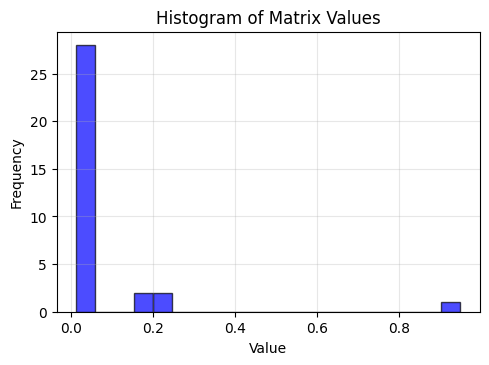

In [77]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(string_nu_mat[np.where(string_nu_mat > 0.01)].flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Matrix Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

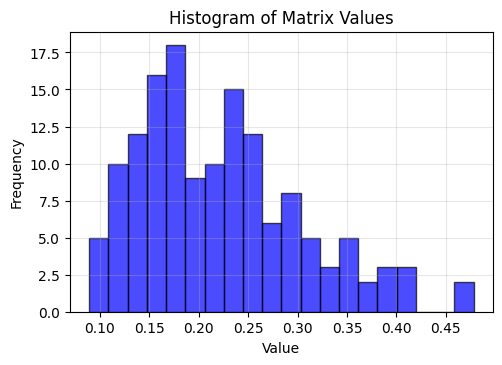

In [80]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(string_on_target_ensemble.flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Matrix Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

### nupack only

In [398]:
nupack_filename = "F24_175mer_defect0.999 (1).csv"

nu_barcodes = []
nu_toeholds = []
nu_toeholds_seqs = [] 
nu_pairings = []
nu_pairings_seqs = []

with open(nupack_filename, "r",encoding='utf-8-sig') as f:
    reader = csv.reader(f)
    for i, row in enumerate(reader):
       if i % 2 == 1:
            barcode = row[1][-barcode_length:]
            toehold = row[1][-(barcode_length+toehold_length):-barcode_length]
            nu_barcodes.append(barcode)
            nu_toeholds_seqs.append(toehold)
            nu_toeholds.append((toehold,0))
            nu_pairings.append((toehold, barcode))
            nu_pairings_seqs.append(toehold + barcode)

In [399]:
nu_toehold_data = evaluate_combinations(nu_toeholds_seqs, model, conc, ncores)

nu_barcode_data = evaluate_barcodes(nu_barcodes, nu_toeholds_seqs, model, conc, ncores)

nu_evaluated_pairings = evaluate_pairings(nu_pairings_seqs, my_model=model, ncores=ncores)

print(nu_toehold_data)
print(nu_barcode_data)
print(nu_evaluated_pairings)


8385it [00:01, 5581.86it/s]                     
100%|██████████| 130/130 [00:12<00:00, 10.66it/s]


(4.0, 10.515682766845558)
[0.3279606308509117, 0.9567504216044259, 0.11717876546970897, 2.7033207777516906e-05, 0.4772569538847144, 0.1072684792230768, 0.4566008706796791, 0.9874872151475969]


100%|██████████| 130/130 [00:01<00:00, 75.64it/s] 

(1.5737534207374329, 10.557141905069424, 0.047659966821249004, 2.0103810195936857e-05, 0.255241212711854, 0.13159436537100838, 0.3250686386274749, 0.9662497705573252)
(4.0, 10.515682766845558, 0.3279606308509117, 0.9567504216044259, 0.11717876546970897, 2.7033207777516906e-05, 0.4772569538847144, 0.1072684792230768, 0.4566008706796791, 0.9874872151475969)
(11, 0.4743378794576248, 0.12403408735581796)


In [73]:
nus = []
for i in range(len(nu_pairings)):
    nus.append(nu_pairings[i][0] + nu_pairings[i][1])
duplex = True
nu_nu_mat, nu_on_t = nupack_matrix_mp(nus, model, conc, ncores, duplex)
nu_off_target_ensemble, nu_on_target_ensemble = ensemble_matrix_mp(nus, model, 
                                                                 ncores, duplex)

Generating...



100%|██████████| 130/130 [00:07<00:00, 16.75it/s]


Generating...



100%|██████████| 130/130 [00:08<00:00, 14.45it/s]


In [58]:
print(np.max(nu_on_target_ensemble))
print(np.min(nu_off_target_ensemble))
print(np.min(nu_on_t))
print(np.max(nu_nu_mat))


0.47801429147879476
0.6487149308781756
0.9971334773471247
0.9486774341126201

0.474337879457625
0.585219915600472
0.9983661814696355
0.09995435120612212


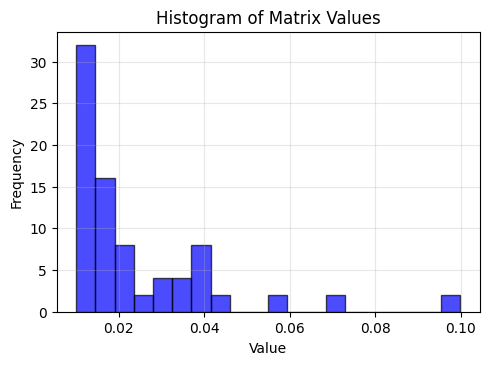

In [78]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(nu_nu_mat[np.where(nu_nu_mat > 0.01)].flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Matrix Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

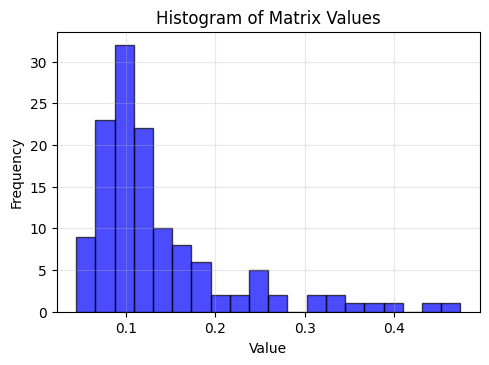

In [79]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(nu_on_target_ensemble.flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of on target ensemble Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

In [74]:
val = np.argmax(nu_on_target_ensemble)
print(val)
print(nu_on_target_ensemble[val])
print(nus[val])

49
0.474337879457625
CGGCTCGGGCACCGGCCGTAGCTACACC


In [ ]:
# string 
[(2.9029464085453385, 0.019384098926767467, 0.48608290528343473, 0.24525809819689987)]
[(6.0, 0.30622709688375205, 0.10942333835997256, 0.5416310372631032, 0.4393126596826236)]
[(9, 0.47801429147879465)]

# nu
[(1.5737534207374329, 0.047659966821249004, 0.255241212711854, 0.3250686386274749)]
[(4.0, 0.3279606308509117, 0.11717876546970897, 0.4772569538847144, 0.4566008706796791)]
[(11, 0.4743378794576248)]

# nu + string 
[(2.98486571124462, 0.009142581677511107, 0.3391893518948798, 0.2776340710388775)]
[(5.0, 0.2047249004237998, 0.07074088314382418, 0.4772569538847144, 0.45411891485671674)]
[(9, 0.4743378794576248)]

### dual approach

In [452]:
thermo_filename = "test.csv"

t_barcodes = []
t_toeholds = []
t_toeholds_seqs = [] 
t_pairings = []
t_pairings_seqs = []
i = 0
with open(thermo_filename, "r",encoding='utf-8-sig') as f:
    reader = csv.reader(f)
    row = next(reader, None)
    while row is not None:
        next_row = next(reader, None)
        if row[1] == "top" and next_row[1] == "top":
            i+=1 
            barcode = row[3][-barcode_length:]
            toehold = row[3][-(barcode_length+toehold_length):-barcode_length]
            t_barcodes.append(barcode)
            t_toeholds_seqs.append(toehold)
            t_toeholds.append((toehold,0))
            t_pairings.append((toehold, barcode))
            t_pairings_seqs.append(toehold + barcode)
        row = next_row

In [455]:
t_toehold_data = evaluate_combinations(t_toeholds_seqs, model, conc, ncores)

t_barcode_data = evaluate_barcodes(t_barcodes, t_toeholds_seqs, model, conc, ncores)

t_evaluated_pairings = evaluate_pairings(t_pairings_seqs, my_model=model, ncores=ncores)

print(t_toehold_data)
print(t_barcode_data)
print(t_evaluated_pairings)


10296it [00:01, 5575.82it/s]                   
100%|██████████| 144/144 [00:01<00:00, 82.79it/s]

(2.870538114543114, 10.639185886873179, 0.010391622012654747, 9.185492959818673e-06, 0.33043277707604746, 0.13917920644782422, 0.303168960392194, 0.9681613912898321)
(5.0, 10.422591297591298, 0.2279040636825167, 0.9477440280812045, 0.014018889307724679, 8.384954575106092e-06, 0.5258149094971135, 0.1970469730778174, 0.5800373071457577, 0.9878317839366202)
(10, 0.4097023354377479, 0.22024504747135715)


In [114]:
ts_pairings = []
for i in range(len(t_pairings)):
    ts_pairings.append(t_pairings[i][0] + t_pairings[i][1])
duplex = True
t_nu_mat, t_on_t = nupack_matrix_mp(ts_pairings, model, conc, ncores, duplex)
t_off_target_ensemble, t_on_target_ensemble = ensemble_matrix_mp(ts_pairings, model, 
                                                                 ncores, duplex)

Generating...



100%|██████████| 168/168 [00:09<00:00, 18.39it/s]

Generating...




100%|██████████| 168/168 [00:10<00:00, 15.55it/s]


In [115]:
print(np.max(t_on_target_ensemble))
print(np.min(t_off_target_ensemble))
print(np.min(t_on_t))
print(np.max(t_nu_mat))

"string"
0.47801429147879476
0.6487149308781756
0.9971334773471247
0.9486774341126201

"nupack only"
0.474337879457625
0.585219915600472
0.9983661814696355
0.09995435120612212

0.474337879457625
0.5849044641487232
0.9969761287983164
0.23917304827543895


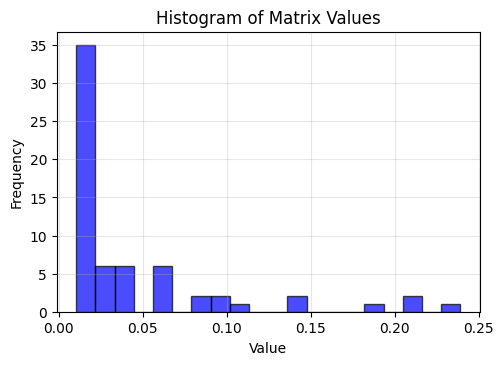

In [118]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(t_nu_mat[np.where(t_nu_mat > 0.01)].flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Matrix Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

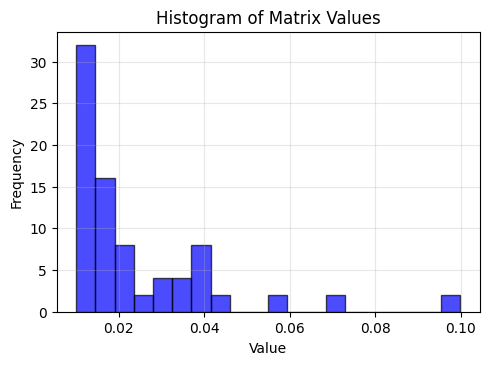

In [142]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(nu_nu_mat[np.where(nu_nu_mat > 0.01)].flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Matrix Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

In [140]:
temp = string_nu_mat[np.where(string_nu_mat > 0.01)]
temp = temp[np.where(temp < 0.5)]

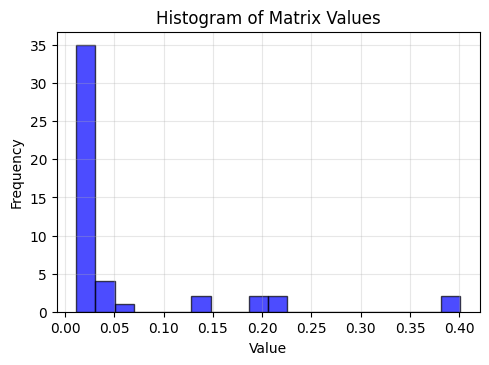

In [141]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.hist(temp.flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Matrix Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

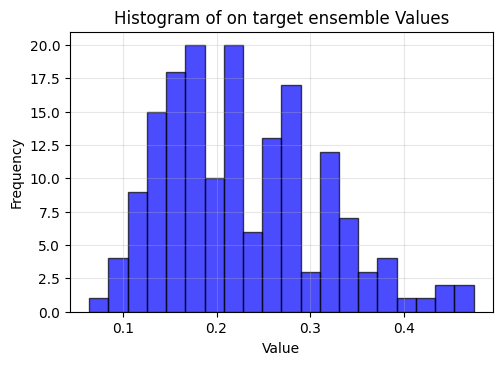

In [120]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(t_on_target_ensemble.flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of on target ensemble Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

In [121]:
val = np.argmax(t_on_target_ensemble)
print(val)
print(t_on_target_ensemble[val])
print(ts_pairings[val])

69
0.474337879457625
CGGCTCGGGCACCGGCCGTAGCTACACC
